In [1]:
import zipfile, os

# 1) 경로 설정 (본인 환경에 맞게 수정)
ZIP_PATH   = r"C:\대외활동\2026\Oracle Analytics & AI 기반 정책 인사이트 프로젝트\Wallet_CallTaxi.zip"
WALLET_DIR = r"C:\oracle\wallet"     # 경로에 한글/공백 없는 곳 권장

# 2) 압축 해제
os.makedirs(WALLET_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(WALLET_DIR)

print(os.listdir(WALLET_DIR))

['cwallet.sso', 'ewallet.p12', 'ewallet.pem', 'keystore.jks', 'ojdbc.properties', 'README', 'sqlnet.ora', 'tnsnames.ora', 'truststore.jks', 'Wallet_CallTaxi.zip']


In [2]:
import oracledb, getpass

WALLET_DIR = r"C:\oracle\wallet"

conn = oracledb.connect(
    user="ADMIN",
    password="Calltaxi2026!",
    dsn="calltaxi_high",                    # ③에서 확인한 이름
    config_dir=WALLET_DIR,
    wallet_location=WALLET_DIR,
    wallet_password="Calltaxi2026!",
)


In [3]:
with conn.cursor() as cur:
    cur.execute("SELECT sysdate, user FROM dual")
    print(cur.fetchone())

(datetime.datetime(2026, 7, 25, 2, 48, 13), 'ADMIN')


In [4]:
import pandas as pd

df = pd.read_sql("""
    SELECT table_name, num_rows
    FROM user_tables
    ORDER BY table_name
""", conn)
print(df)

C:\Users\seoye\AppData\Local\Temp\ipykernel_298236\1229118901.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


                  TABLE_NAME  NUM_ROWS
0              CALLTAXI_2025   1488498
1           CALLTAXI_BEST100     20400
2     CALLTAXI_BOARDING_2025   1729476
3             CALLTAXI_DAILY       203
4               CITY_PARKING       122
5  DBTOOLS$EXECUTION_HISTORY         2
6             PUBLIC_PARKING      2189


| 번호 | 컬럼명 | 설명 |
|----|------------------|--------------|
| 1  | LIST_TOTAL_COUNT | 총조회건수 |
| 2  | RESULT.CODE      | 결과코드 |
| 3  | RESULT.MESSAGE   | 메시지 |
| 4  | NO               | 차량고유번호 |
| 5  | CARTYPE          | 차량타입 |
| 6  | RECEIPTIME       | 예정일시 |
| 7  | SETTIME          | 배차일시 |
| 8  | RIDETIME         | 승차일시 |
| 9  | STARTPOS1        | 출발지구군 |
| 10 | STARTPOS2        | 출발지상세 |
| 11 | ENDPOS1          | 목적지구군 |
| 12 | ENDPOS2          | 목적지상세 |


In [5]:
df = pd.read_sql("SELECT * FROM CALLTAXI_2025", conn)
print(df.shape)


C:\Users\seoye\AppData\Local\Temp\ipykernel_298236\2487284266.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM CALLTAXI_2025", conn)


KeyboardInterrupt: 

In [6]:
import pandas as pd

path = r"C:\Users\seoye\Downloads\서울시설공단_장애인콜택시 탑승내역_20251231.csv"
df = pd.read_csv(path, encoding="utf-8-sig")   # 깨지면 encoding="cp949"

print(df.shape)
print(df.columns.tolist())
df.head()


(1729476, 15)
['접수일시', '예정일시', '배차일시', '승차일시', '하차일시', '취소일시', '출발구', '출발동', '목적구', '목적동', '이용목적', '요금', '승차거리', '차량구분', '장애유형']


,접수일시,예정일시,배차일시,승차일시,하차일시,취소일시,출발구,출발동,목적구,목적동,이용목적,요금,승차거리,차량구분,장애유형
0,2025-01-01 00:01:26.127,2025-01-01 00:01:26.127,2025-01-01 00:27:31.307,2025-01-01 00:49:52.967,2025-01-01 01:35:06.747,NaN,용산구,남영동,강북구,수유제2동,기타,3400.0,17667,특장차,지체
1,2025-01-01 00:03:10.557,2025-01-01 00:03:10.557,2025-01-01 00:14:39.800,NaN,NaN,2025-01-01 00:21:15.000,영등포구,여의동,강서구,화곡제6동,기타,NaN,0,특장차,뇌병
2,2025-01-01 00:03:31.230,2025-01-01 00:04:00.000,2025-01-01 00:19:41.900,2025-01-01 00:36:18.433,2025-01-01 00:49:45.857,NaN,노원구,상계5동,노원구,하계1동,기타,1500.0,2910,특장차,뇌병
3,2025-01-01 00:03:40.573,2025-01-01 00:04:00.000,2025-01-01 00:33:41.650,2025-01-01 00:53:48.440,2025-01-01 01:33:38.120,NaN,영등포구,당산제1동,중구,명동,기타,2900.0,10421,특장차,지체
4,2025-01-01 00:04:15.077,2025-01-01 00:04:15.077,2025-01-01 00:06:33.790,2025-01-01 00:40:07.840,2025-01-01 01:10:15.110,NaN,송파구,오금동,서초구,내곡동,기타,3000.0,11943,특장차,지체


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

# 예정 → 배차 → 승차 (한글 컬럼)
for c in ['예정일시', '배차일시', '승차일시']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# 파생값
df['대기분']  = (df['배차일시'] - df['예정일시']).dt.total_seconds() / 60   # 예정→배차
df['배차후분'] = (df['승차일시'] - df['배차일시']).dt.total_seconds() / 60   # 배차→승차

# 시계열 기준 = 승차일시
df['date'] = df['승차일시'].dt.normalize()
df['시각'] = df['승차일시'].dt.hour
df['요일'] = df['승차일시'].dt.dayofweek   # 0=월 ... 6=일

print(df[['예정일시','배차일시','승차일시','date','시각','요일']].head())


                     예정일시                    배차일시                    승차일시  \
0 2025-01-01 00:01:26.127 2025-01-01 00:27:31.307 2025-01-01 00:49:52.967   
1 2025-01-01 00:03:10.557 2025-01-01 00:14:39.800                     NaT   
2 2025-01-01 00:04:00.000 2025-01-01 00:19:41.900 2025-01-01 00:36:18.433   
3 2025-01-01 00:04:00.000 2025-01-01 00:33:41.650 2025-01-01 00:53:48.440   
4 2025-01-01 00:04:15.077 2025-01-01 00:06:33.790 2025-01-01 00:40:07.840   

        date   시각   요일  
0 2025-01-01  0.0  2.0  
1        NaT  NaN  NaN  
2 2025-01-01  0.0  2.0  
3 2025-01-01  0.0  2.0  
4 2025-01-01  0.0  2.0  


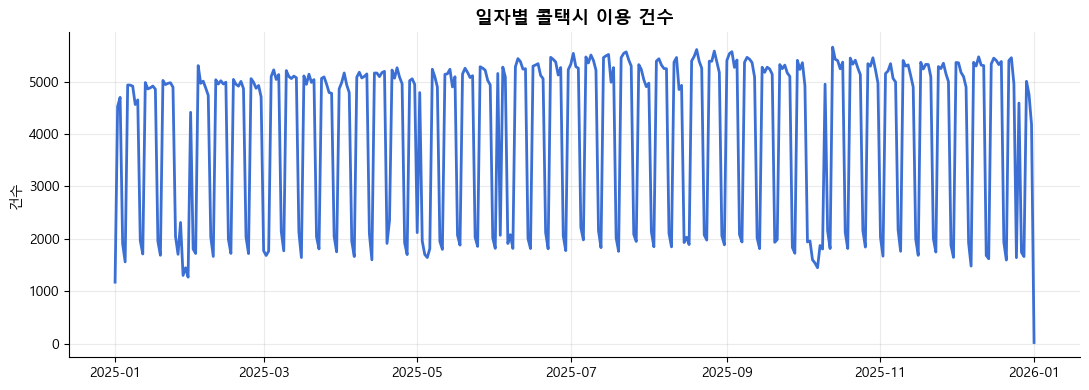

In [9]:
# 1. 일자별 이용량 추이
daily = df.groupby('date').size()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily.index, daily.values, color='#3b6fd4', lw=2)
ax.set_title('일자별 콜택시 이용 건수', fontsize=13, weight='bold')
ax.set_ylabel('건수')
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


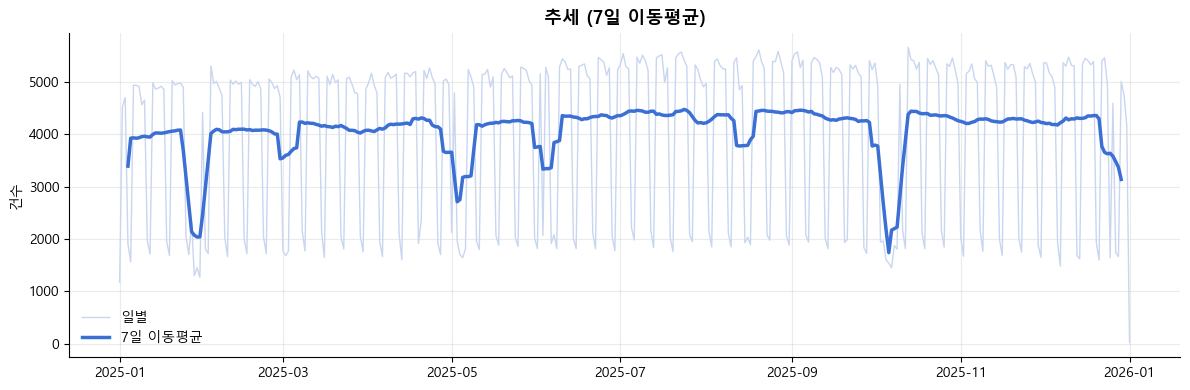

In [ ]:
# 1-1) 7일 이동평균으로 추세만 보기
daily = df.groupby('date').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily.index, daily.values, color='#c9d6f0', lw=1, label='일별')
ax.plot(daily.index, daily.rolling(7, center=True).mean(),
        color='#3b6fd4', lw=2.5, label='7일 이동평균')
ax.set_title('추세 (7일 이동평균)', fontsize=13, weight='bold')
ax.set_ylabel('건수'); ax.legend(frameon=False)
ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


## 1-2) 그래프 해석. 일자별 이용 건수 추세 해석 (7일 이동평균)
- 1) 기본 수준 — 안정적
평상시 일평균 **약 4,000~4,500건**에서 큰 변동 없이 유지됨. 연중 폭발적 증가나 감소는 없는 **성숙기 수요 패턴**.
- 2) 뚝 떨어지는 골짜기 = 명절/연휴 효과 (가장 뚜렷한 신호)
급락 시점이 한국 연휴와 정확히 일치:

| 시기 | 최저 수준 | 원인 |
|------|-----------|------|
| 2025년 1월 말~2월 초 | ~2,000건 | **설날** 연휴 |
| 2025년 5월 초 | ~3,200건 | 어린이날·부처님오신날 등 5월 초 연휴 |
| 2025년 9월 말~10월 초 | ~1,400건 (**연중 최저**) | **추석** 연휴 — 낙폭 최대 |
| 8월 중순 | 소폭 하락 | 광복절/여름 휴가철 추정 |

→ 이 데이터의 **가장 강한 계절성은 "연휴 급감"**. 장애인 콜택시가 출퇴근·치료 등 일상 이동 중심이라 연휴에 수요가 크게 감소.

- 3) 완만한 연중 흐름
연초(1월) 3,800대 → 여름철(6~9월) 4,400대로 **완만히 상승** 후 겨울로 가며 약간 둔화. 계절 자체 영향은 연휴 효과에 비해 작음.

- 4) 맨 끝 12월 말 급락은 주의
2025-12 말 급락은 실제 감소일 수도 있으나 **마지막 날 데이터가 잘렸을 가능성**이 큼. 해석에 반영하기 전 마지막 며칠 원본 확인 필요.


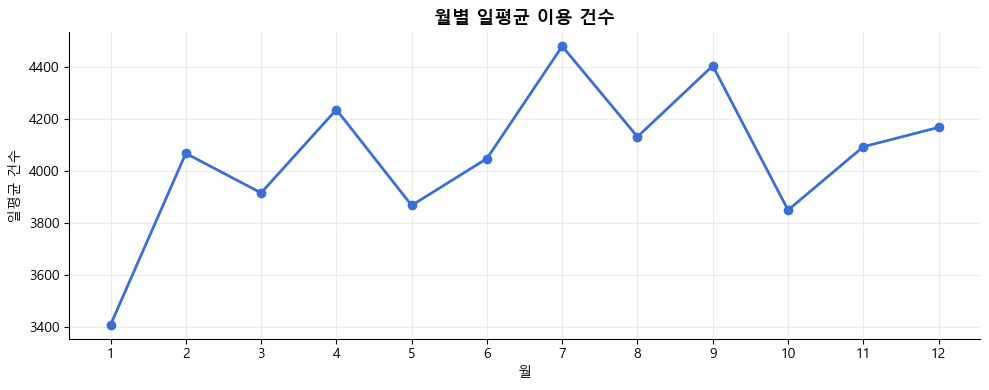

In [ ]:
# 1-2) 월별 평균 — 계절(월) 패턴
monthly = df.groupby(df['date'].dt.month).size() / df.groupby(df['date'].dt.month)['date'].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly.index, monthly.values, color='#3b6fd4', lw=2, marker='o', ms=6)
ax.set_title('월별 일평균 이용 건수', fontsize=13, weight='bold')
ax.set_xlabel('월'); ax.set_ylabel('일평균 건수'); ax.set_xticks(range(1,13))
ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


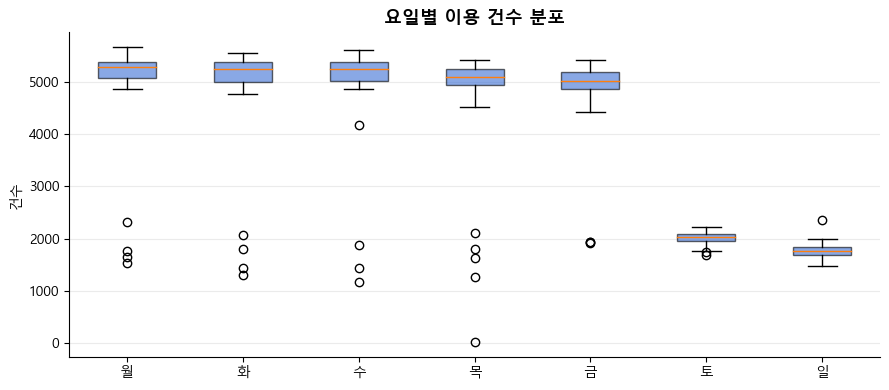

In [ ]:
# 1-3) 요일별 분포 (박스플롯) — 주간 계절성 크기 확인
labels = ['월','화','수','목','금','토','일']
data = [daily[daily.index.dayofweek == d].values for d in range(7)]

fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot(data, labels=labels, patch_artist=True)
for box in bp['boxes']:
    box.set(facecolor='#3b6fd4', alpha=0.6)
ax.set_title('요일별 이용 건수 분포', fontsize=13, weight='bold')
ax.set_ylabel('건수')
ax.grid(alpha=0.25, axis='y'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()


C:\Users\seoye\AppData\Local\Temp\ipykernel_298236\3760859888.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


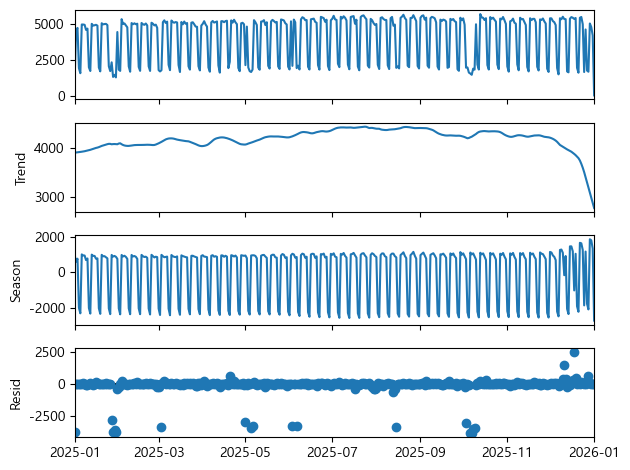

In [18]:
# 1-4) STL 분해 — 추세/계절/잔차 자동 분리
from statsmodels.tsa.seasonal import STL

s = daily.asfreq('D').interpolate()      # 빠진 날짜 보간
res = STL(s, period=7, robust=True).fit()  # period=7 → 주간 계절성

res.plot()
plt.tight_layout(); plt.show()


## 1-3) 그래프 해석. STL 시계열 분해 해석 (주간, period=7)

 ① 원본 (맨 위)
톱니 = 주간 패턴. 아래 세 성분(추세 + 계절 + 잔차)의 합.

② Trend (추세) — 안정 + 연말 급락 주의
    - 1월 ~4,000 → 여름·가을(6~10월) **~4,500으로 완만히 상승** 후 유지. "성숙기 안정 수요"와 일치.
    - **12월 말 ~2,700 급락**은 조심해서 볼 것. STL 추세는 양 끝단이 왜곡되기 쉽고(edge effect), 마지막 날 데이터 잘림까지 겹침. → **실제 추세 하락으로 단정 금지.**

③ Season (계절 = 주간) — 매우 규칙적, 핵심 신호
    - 매주 **평일 약 +700 ↔ 주말 약 −2,000**, 진폭 2,500 이상. 전체 수준(~4,000) 대비 매우 큼. → **주간 계절성이 지배적**이라는 결정적 증거.
    - 1년 내내 거의 일정 = 요일 효과가 안정적으로 반복.

④ Resid (잔차) — 대부분 0, 큰 음의 튐 = 연휴
    - 평소엔 0 근처에 밀집 → **모델이 대부분 잘 설명**(주간 계절성으로 설명됨).
    - **−2,000~−3,000짜리 큰 음의 이상치** = **설·5월 초·추석** 시점. 주간 계절성으로 설명 안 되는 **비정기적 연휴 급감**이 잔차로 나타남.
    - 연말(12월) 잔차 변동 확대 역시 edge / 데이터 잘림 영향.

결론
    1. **주간 계절성(주말 급감)이 압도적** — Season 진폭이 전체 수준의 절반 이상.
    2. **추세는 연중 안정**(여름 소폭↑), 단 **연말 급락은 경계 왜곡**이라 신뢰하지 않음.
    3. **연휴(설·추석 등)는 계절성이 아닌 "이상치"로 잔차에 포착** → 별도 변수로 다뤄야 함.


In [ ]:
# 정상성 검정
from statsmodels.tsa.stattools import adfuller, kpss

s = daily.asfreq('D').interpolate()
print("ADF  p =", adfuller(s)[1])          # p<0.05 → 정상(차분 덜 필요)
print("KPSS p =", kpss(s, nlags='auto')[1]) # p>0.05 → 정상
# 차분 안해도 됨

ADF  p = 0.0001822832248362452
KPSS p = 0.1


C:\Users\seoye\AppData\Local\Temp\ipykernel_298236\927367699.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS p =", kpss(s, nlags='auto')[1]) # p>0.05 → 정상


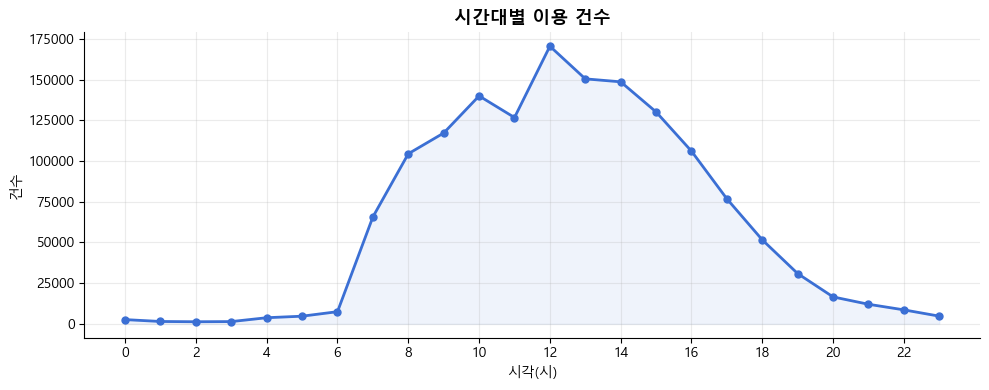

In [ ]:
# 2. 시간대별 수요 곡선
hourly = df.groupby('시각').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly.index, hourly.values, color='#3b6fd4', lw=2, marker='o', ms=5)
ax.fill_between(hourly.index, hourly.values, color='#3b6fd4', alpha=0.08)
ax.set_title('시간대별 이용 건수', fontsize=13, weight='bold')
ax.set_xlabel('시각(시)'); ax.set_ylabel('건수')
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


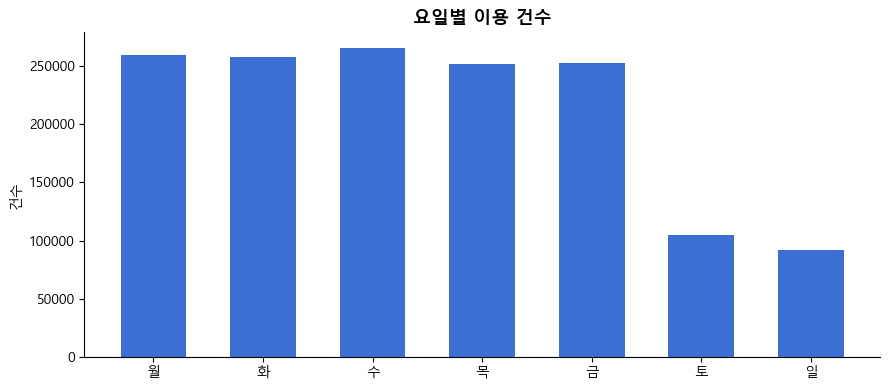

        건수  평균대기
요일              
0   259676  18.2
1   257610  19.0
2   265641  20.2
3   251633  18.2
4   252255  20.0
5   104544  20.4
6    92059  21.2


In [ ]:
# 3. 요일별 이용 건수 + 평균 대기시간
labels = ['월','화','수','목','금','토','일']

# by_dow = df.groupby('요일').agg(건수=('no','size'), 평균대기=('대기분','mean'))
by_dow = df.groupby('요일').agg(
    건수=('승차일시', 'size'),      # 아무 컬럼이나 'size'면 행 수
    평균대기=('대기분', 'mean'),
).reindex(range(7))                  # 혹시 빠진 요일 있어도 월~일 순서 보장

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels, by_dow['건수'], color='#3b6fd4', width=0.6)
ax.set_title('요일별 이용 건수', fontsize=13, weight='bold')
ax.set_ylabel('건수')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print(by_dow.round(1))
